In [1]:
import os
# Mute OpenCV warnings BEFORE importing cv2
os.environ["OPENCV_LOG_LEVEL"] = "FATAL" 

# Install albumentations if not already available
!pip install -q albumentations

import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset Splitting
The Inria Aerial Image Labeling Dataset provides 36 image tiles (5000x5000 pixels) for 5 different regions (Austin, Chicago, Kitsap County, Western Tyrol, Vienna) in the `train` directory with ground truth masks. The provided `test` directory does not contain public masks. 

To meet the project requirement for a train/validation/test split and measurable evaluation, we will partition the 36 tiles from the provided `train` folder as follows:
* **Train**: Tiles 1 to 25
* **Validation**: Tiles 26 to 30
* **Test**: Tiles 31 to 36

In [2]:
import os
import glob

# 1. Dynamically find the images directory inside Kaggle's input folder
image_search_paths = glob.glob('/kaggle/input/**/train/images/*', recursive=True)

if not image_search_paths:
    print("ERROR: Could not find the images directory. Make sure the dataset is attached to the notebook.")
else:
    # 2. Extract the actual parent directory and file extension
    train_dir = os.path.dirname(os.path.dirname(image_search_paths[0]))
    IMAGE_DIR = os.path.join(train_dir, 'images')
    MASK_DIR = os.path.join(train_dir, 'gt')
    
    # Auto-detect the file extension (e.g., .tif or .png)
    ext = os.path.splitext(image_search_paths[0])[1]
    
    print(f"Successfully located IMAGE_DIR: {IMAGE_DIR}")
    print(f"Successfully located MASK_DIR: {MASK_DIR}")
    print(f"Detected file extension: {ext}\n")

    cities = ['austin', 'chicago', 'kitsap', 'tyrol-w', 'vienna']

    train_imgs, train_masks = [], []
    val_imgs, val_masks = [], []
    test_imgs, test_masks = [], []

    # 3. Perform the split
    for city in cities:
        for i in range(1, 37):
            img_name = f"{city}{i}{ext}"
            img_path = os.path.join(IMAGE_DIR, img_name)
            mask_path = os.path.join(MASK_DIR, img_name)
            
            # Verify file exists before adding
            if os.path.exists(img_path) and os.path.exists(mask_path):
                if i <= 25:
                    train_imgs.append(img_path)
                    train_masks.append(mask_path)
                elif i <= 30:
                    val_imgs.append(img_path)
                    val_masks.append(mask_path)
                else:
                    test_imgs.append(img_path)
                    test_masks.append(mask_path)

    print(f"Total Train Images: {len(train_imgs)}")
    print(f"Total Validation Images: {len(val_imgs)}")
    print(f"Total Test Images: {len(test_imgs)}")

Successfully located IMAGE_DIR: /kaggle/input/datasets/sagar100rathod/inria-aerial-image-labeling-dataset/AerialImageDataset/train/images
Successfully located MASK_DIR: /kaggle/input/datasets/sagar100rathod/inria-aerial-image-labeling-dataset/AerialImageDataset/train/gt
Detected file extension: .tif

Total Train Images: 125
Total Validation Images: 25
Total Test Images: 30


## Patch Extraction
Because the original images are 5000x5000 pixels, feeding them directly into a neural network will cause GPU Out-Of-Memory (OOM) errors. We define a custom PyTorch `Dataset` to dynamically slice the images and masks into manageable patches (e.g., 512x512 pixels) during loading.

In [3]:
class InriaPatchDataset(Dataset):
    def __init__(self, image_paths, mask_paths, patch_size=512, stride=512, transform=None):
        self.patch_size = patch_size
        self.stride = stride
        self.transform = transform
        self.samples = []
        
        # Build a list of coordinate patches for each image
        for img_p, msk_p in zip(image_paths, mask_paths):
            # Inria images are consistently 5000x5000
            for y in range(0, 5000 - patch_size + 1, stride):
                for x in range(0, 5000 - patch_size + 1, stride):
                    self.samples.append((img_p, msk_p, x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, msk_path, x, y = self.samples[idx]
        
        # Read the image and crop the patch
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        patch_img = img[y:y+self.patch_size, x:x+self.patch_size]

        # Read the mask and crop the patch
        mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        patch_mask = mask[y:y+self.patch_size, x:x+self.patch_size]
        
        # Convert ground truth mask to binary (0: background, 1: building)
        patch_mask = (patch_mask > 128).astype(np.float32)

        # Apply Albumentations transforms if provided
        if self.transform:
            augmented = self.transform(image=patch_img, mask=patch_mask)
            patch_img = augmented['image']
            patch_mask = augmented['mask']
        else:
            # Default to tensor conversion
            patch_img = ToTensorV2()(image=patch_img)['image'].float() / 255.0
            patch_mask = torch.tensor(patch_mask, dtype=torch.float32)

        # Add channel dimension to mask (1, H, W)
        if len(patch_mask.shape) == 2:
            patch_mask = patch_mask.unsqueeze(0)

        return patch_img, patch_mask

## Exploratory Data Analysis (EDA)
To ensure our dataloader is cropping patches correctly and that our binary masks align with the aerial imagery, we will visualize a few random patches from our training set. This provides qualitative visual evidence of our dataset preparation.

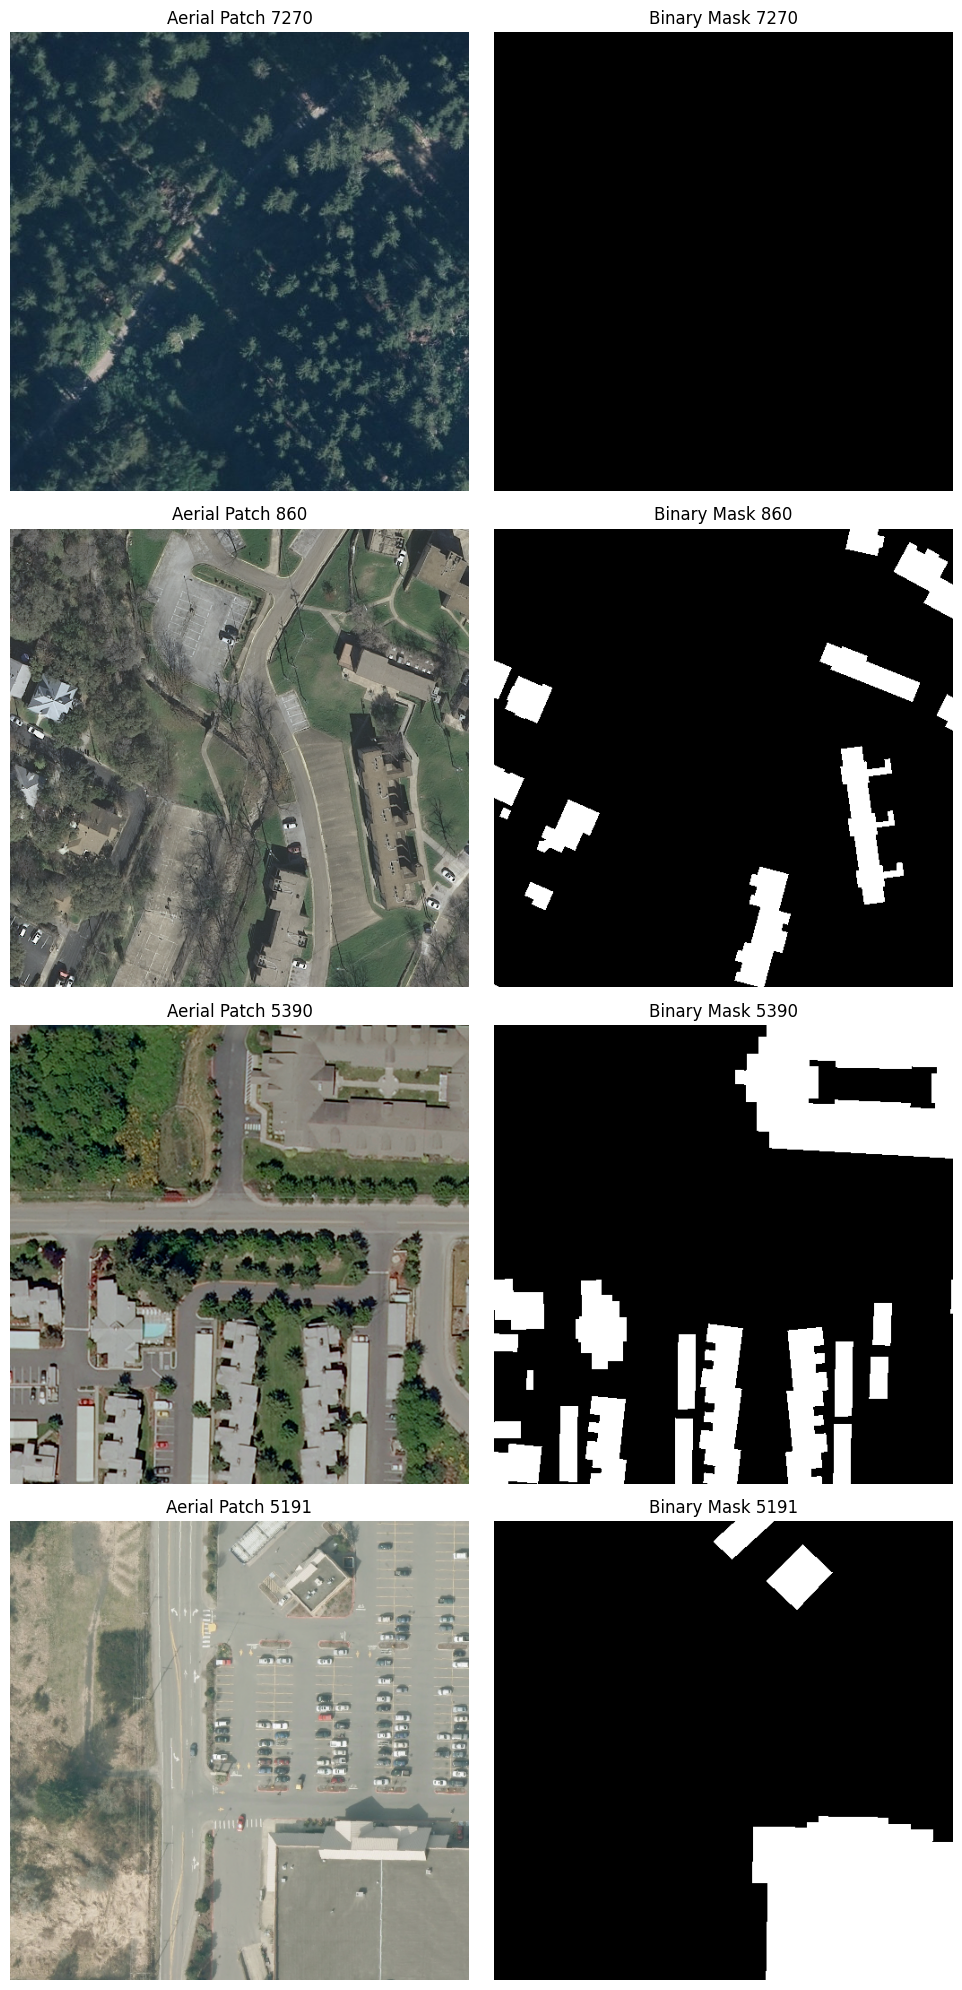

In [4]:
# Initialize dataset without heavy augmentations for EDA visualization
eda_dataset = InriaPatchDataset(
    image_paths=train_imgs, 
    mask_paths=train_masks, 
    patch_size=512, 
    stride=512
)

# Function to plot image and mask side-by-side
def visualize_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5 * num_samples))
    
    for i in range(num_samples):
        # Pick random patches
        idx = np.random.randint(0, len(dataset))
        img_tensor, mask_tensor = dataset[idx]
        
        # Convert tensors back to numpy for matplotlib
        # Img: (C, H, W) -> (H, W, C)
        img_np = img_tensor.permute(1, 2, 0).numpy()
        # Mask: (1, H, W) -> (H, W)
        mask_np = mask_tensor.squeeze(0).numpy()
        
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"Aerial Patch {idx}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask_np, cmap='gray')
        axes[i, 1].set_title(f"Binary Mask {idx}")
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_samples(eda_dataset, num_samples=4)